In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [2]:
from PSF_Acquire import * 
from Plot_helpers import *
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300

In [4]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05

L_ffp = 0.005              # FFP size [mm]
grid_ffp = 128

In [5]:
r_pupil = f * num_apt
r_bfp = L_bfp / 2
na_eff = num_apt
#effective NA can be limited by the size of the back focal plane
if r_bfp < r_pupil:
    na_eff = r_bfp / f
alpha = np.arcsin(na_eff / n)

theta_grid_size = 64
R_BFP = r_bfp
z = 0

In [6]:
psf_grid = Grid(L_ffp, grid_ffp, 0.001, -0.001, 0)
aberration = Aberration([[-4, 4]], [np.pi/4], alpha)
microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, theta_grid_size)

In [12]:
x, y, I = microscope.compute_PSF(psf_grid, aberration)

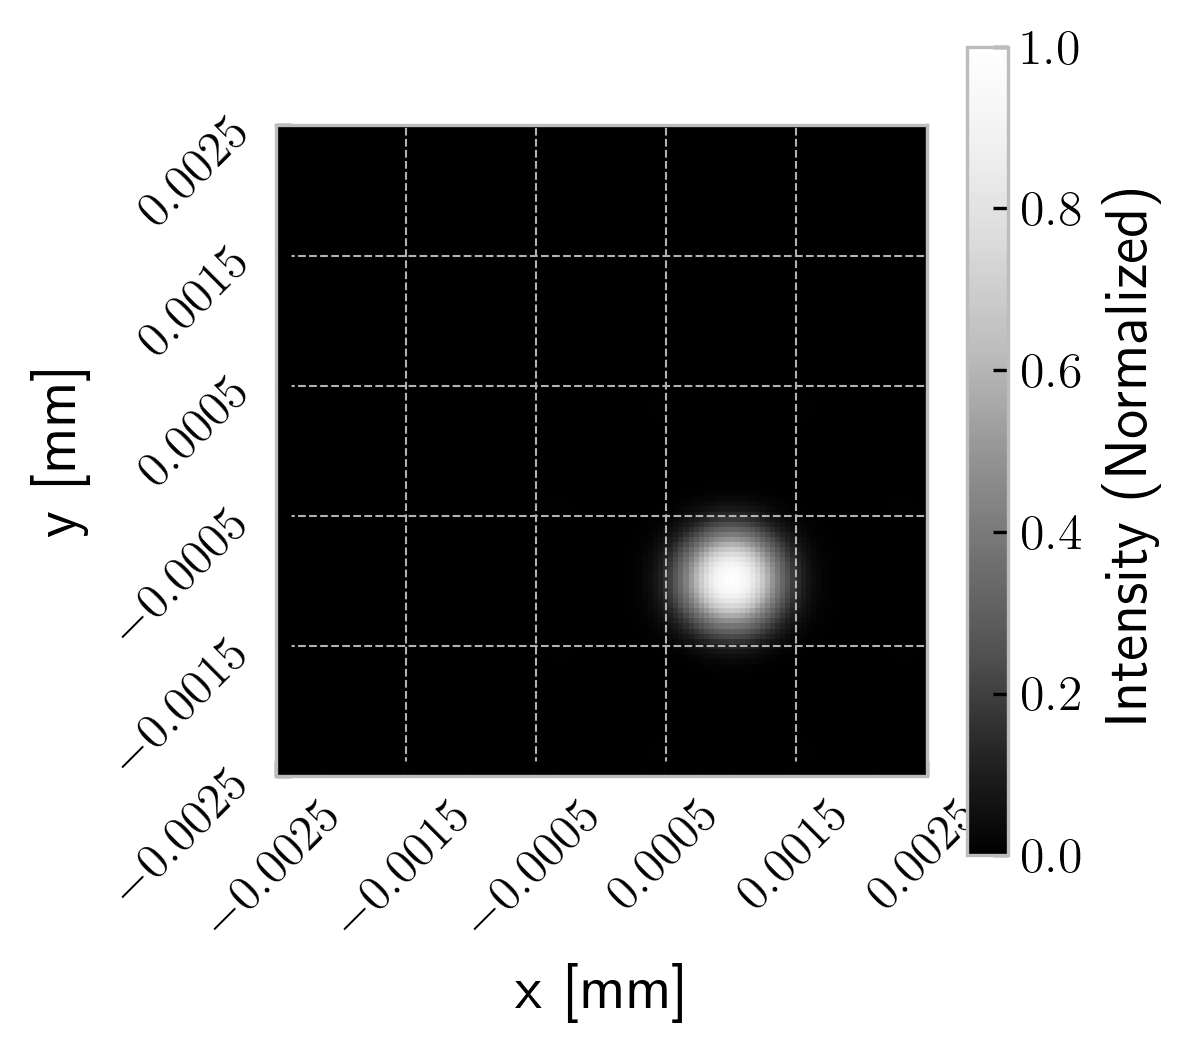

In [13]:
plot_intensity(x, y, I)